# Grupo 6: Comportamiento de la Poblacion y Toma de Decisiones
## CC2017: Modelacion y Simulacion, Examen Practico (Terremoto Ciudad UVG)

Este notebook implementa un **modelo basado en agentes (ABM)** de la decision
de evacuacion de la poblacion tras el terremoto
(`data/raw/Grupo6_ComportamientoPoblacional.xlsx`, hoja `Datos_Grupo6`):

- Composicion demografica y vulnerabilidad real por zona (3 niveles:
  autonomo / necesita asistencia / dependiente).
- Redes sociales por zona con grado promedio, velocidad de propagacion de
  informacion y probabilidad de que la informacion que circula sea correcta
  o sea rumor, todo heterogeneo por zona.
- Parametros de comportamiento individual (evacuacion espontanea, ayuda a
  vecinos, uso de redes sociales, confianza en canales oficiales).

> **Unico supuesto documentado:** el Excel no incluye la
> poblacion absoluta por zona (solo porcentajes demograficos y de
> vulnerabilidad). El enunciado general solo da el total de la ciudad
> (250,000 hab.), sin desglose por zona. Se asume reparto igualitario
> (50,000/zona) hasta que se confirme lo contrario en el intercambio
> presencial. Ver `src/grupo6_model.py`, variable `POBLACION_ZONA`.

### Justificacion del paradigma (ABM)
Se elige **ABM** porque la pregunta central de este grupo depende de
**decisiones individuales heterogeneas** (umbral de riesgo propio,
vulnerabilidad, acceso a smartphone, confianza en canales oficiales) y de
una **interaccion local no lineal**: la decision de evacuar de una persona
se propaga por su red de contactos reales (grado promedio y velocidad de
propagacion medidos por zona en el Excel). Un modelo de Dinamica de
Sistemas (SD) trataria la evacuacion como un stock agregado con un flow de
entrada gobernado por una tasa promedio, asumiendo mezcla homogenea: todo
el mundo tendria la misma probabilidad de "contagiarse" de la decision de
evacuar, sin importar en que zona esta ni con quien esta conectado. Eso es
precisamente lo que el Excel contradice: el grado de red, la velocidad de
propagacion y la probabilidad de rumor son distintos en cada zona, y esa
heterogeneidad de la red es la que produce que Z4 evacue proporcionalmente
mas rapido que Z1 pese a menor dano/aislamiento supuesto. Un ABM con una
red social explicita conserva esa estructura; un stock agregado la borra
por construccion.

Dicho de otro modo, la dinamica de "una persona ve evacuar a sus vecinos y
decide evacuar tambien" es matematicamente un loop reforzador (mas
evacuados generan mas evacuados), analogo al mecanismo detras de un
contagio o de la adopcion de una innovacion. Ese loop agregado se podria
escribir como una sola ecuacion diferencial (la misma estructura que
gobierna una curva de adopcion o una curva epidemica), pero esa ecuacion
por si sola no distingue una zona de otra ni predice cual satura primero:
solo dice que hay crecimiento reforzado. La pregunta que debe responder
Grupo 6 exige precisamente lo contrario, diferenciar zonas y momentos, asi
que el mecanismo de contagio se implementa sobre una red de agentes en vez
de colapsarlo en una unica ecuacion agregada.

Se descarta DES porque el foco no es una cola de eventos discretos
compitiendo por un recurso compartido (ese es el caso de Grupo 2/3/5), sino
la propagacion de una decision sobre una poblacion heterogenea y su red
social.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd
import networkx as nx

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("No se encontro la raiz del proyecto (directorio src).")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import grupo6_model as m

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.width", 120)


## 1. Datos oficiales cargados desde el Excel

In [2]:
print("Composicion demografica y acceso a smartphone por zona:")
display(m.DEMOGRAFIA)

print("\nParametros de comportamiento (globales):")
display(m.COMPORTAMIENTO)

print("\nRedes sociales por zona:")
display(m.REDES)

print("\nVulnerabilidad y capacidad de autoevacuacion por zona:")
display(m.VULNERABILIDAD)


Composicion demografica y acceso a smartphone por zona:


,pct_menor15,pct_adulto,pct_mayor60,pct_discapacidad,pct_smartphone
zona,,,,,
Z1,0.28,0.54,0.18,0.09,0.61
Z2,0.21,0.62,0.17,0.06,0.84
Z3,0.32,0.55,0.13,0.11,0.52
Z4,0.19,0.67,0.14,0.05,0.88
Z5,0.35,0.50,0.15,0.14,0.39



Parametros de comportamiento (globales):


parametro
Probabilidad de evacuar espontáneamente (sin instrucción)     0.35
Tiempo promedio decisión de evacuación (min)                 18.00
Prob. de ayudar a vecinos antes de evacuar                    0.48
Prob. de buscar información en redes sociales primero         0.67
Prob. de seguir instrucciones oficiales vs. rumores           0.54
Velocidad de evacuación a pie (km/h)                          3.80
Multiplicador vulnerabilidad adultos mayores (velocidad)      0.45
Umbral de daño visible para decidir evacuar (% daño)          0.25
Name: valor, dtype: float64


Redes sociales por zona:


,grado_promedio,pct_contacto_otra_zona,velocidad_prop_h_salto,prob_info_correcta
zona,,,,
Z1,8.2,0.42,0.8,0.61
Z2,12.4,0.58,0.5,0.74
Z3,6.8,0.31,1.1,0.55
Z4,14.1,0.65,0.4,0.81
Z5,5.2,0.22,1.4,0.48



Vulnerabilidad y capacidad de autoevacuacion por zona:


,pct_autonomo,pct_necesita_asistencia,pct_dependiente,indice_riesgo_rezago
zona,,,,
Z1,0.61,0.24,0.15,0.74
Z2,0.78,0.15,0.07,0.42
Z3,0.55,0.28,0.17,0.68
Z4,0.82,0.13,0.05,0.31
Z5,0.48,0.31,0.21,0.82


## 2. Descripcion del modelo (ODD simplificado)

**Entidades y atributos:** agente representativo (super-agente: cada uno
pondera por `poblacion_zona/2000` habitantes reales), con `zona`, `edad`
(menor15/adulto/mayor60, muestreado de la Seccion 1), `smartphone`
(Seccion 1), `tier` de vulnerabilidad (autonomo / necesita_asistencia /
dependiente, Seccion 4), rasgos de comportamiento `espontaneo` y
`ayuda_vecinos` (Bernoulli con las probabilidades de la Seccion 2).

**Zona:** grado promedio de red social, % con contactos fuera de la zona,
velocidad de propagacion de informacion (horas/salto), probabilidad de que
la informacion que circula sea correcta vs. rumor (todo Seccion 3); y
`pct_autonomo/necesita_asistencia/dependiente` + `indice_riesgo_rezago`
(Seccion 4).

**Reglas de comportamiento / ecuaciones de estado** (`src/grupo6_model.py`,
funcion `correr_realizacion`):
1. **Impulso espontaneo:** una fraccion `P_ESPONTANEO=0.35` de agentes
   decide evacuar desde el bloque 0 (el Excel documenta que el tiempo de
   decision, unos 18 min en promedio, es insignificante frente a un bloque
   de 6h).
2. **Difusion de informacion por la red social:** en cada bloque, la
   informacion (de que hay riesgo real) se propaga desde los agentes ya en
   evacuacion hacia sus vecinos, hasta `hops = round(6 / velocidad_prop_zona)` saltos de red. El limite se
   aplica a la zona del agente receptor (p. ej. Z4: unos 15 saltos por
   bloque, contra unos 4 en Z5), por lo que la velocidad heterogenea no se
   reemplaza por un maximo global. Agentes sin smartphone solo reciben la
   informacion boca a boca (alcance de 1 salto).
3. **Decision al ser expuesto:** `P(evacua | expuesto, zona) = prob_info_correcta_zona
   + (1 - prob_info_correcta_zona) * P_SIGUE_OFICIAL`, combina que tan
   confiable es la informacion que circula en esa zona (Seccion 3) con la
   probabilidad global de que la persona igual termine seguiendo
   instrucciones oficiales aunque haya oido un rumor (Seccion 2).
4. **Ayuda a vecinos:** un agente con ese rasgo (Bernoulli 0.48) retrasa su
   propia salida exactamente un bloque de 6h la primera vez que decide
   evacuar.
5. **Restriccion de vulnerabilidad:** un agente `autonomo` evacua en cuanto
   decide hacerlo; uno `necesita_asistencia` o `dependiente` solo evacua si
   recibe asistencia activa ese bloque (`prob_asistencia`, que usa el
   `indice_riesgo_rezago` real de su zona, a mayor rezago, menor
   probabilidad de asistencia a tiempo; los dependientes tienen ademas un
   factor adicional de 0.55 por requerir transporte especializado). Si no
   recibe asistencia, queda registrado como "quiere pero no puede" (insumo
   directo del output b) para Grupo 1).
6. **Ruta / destino:** al evacuar, un agente puede dirigirse a otra zona
   segun `pct_contacto_otra_zona`. El modelo registra la matriz completa de
   origen y destino. Como el Excel no incluye preferencias entre pares de
   zonas, el destino social se distribuye uniformemente entre las otras
   cuatro zonas; este supuesto queda explicito y puede sustituirse si se
   recibe una matriz origen-destino. La diagonal representa el refugio
   oficial y las demas celdas forman el output c para Grupo 1.
7. **Intervencion de senalizacion:** el parametro
   `efectividad_senalizacion` representa la proporcion de personas que iban
   a desviarse hacia otra zona y que una senalizacion dirigida logra
   mantener en la ruta oficial. La Pregunta 2 evalua un escenario explicito
   de 50% de efectividad y lo compara con el escenario base usando las
   mismas 30 semillas.

**Diagrama de estado del agente:**

```
NO EVACUADO (no decidido)
   |  espontaneo=True (bloque 0)
   |  O expuesto por la red Y decide creer el mensaje
   v
QUIERE EVACUAR
   |
   |-- si tiene rasgo "ayuda_vecinos" y aun no espero su bloque --> espera
   |   un bloque y vuelve a QUIERE EVACUAR (habilitado)
   |
   |-- si es autonomo --> EVACUADO (inmediato)
   |
   |-- si necesita_asistencia o es dependiente:
   |       cada bloque se sortea si llega asistencia (tasa creciente con t,
   |       penalizada por el indice de rezago de su zona)
   |       si llega  --> EVACUADO
   |       si no llega --> queda registrado como "quiere pero no puede"
   |                       y vuelve a intentar en el siguiente bloque
   v
EVACUADO (estado terminal; elige destino: refugio oficial u otra zona)
```

Este diagrama es el que efectivamente esta implementado en
`correr_realizacion`: cada condicion de transicion corresponde a una linea
de codigo comentada con la formula correspondiente.

**Tasa de riesgo de la restriccion de vulnerabilidad:** `prob_asistencia`
no es una probabilidad constante por bloque; crece con el tiempo
(`0.10 + 0.04*t`, penalizada por el rezago de la zona), es decir, el riesgo
de que un agente en espera reciba asistencia en el bloque siguiente
aumenta cuanto mas tiempo llevan desplegandose los equipos de rescate. Esa
eleccion no es un detalle tecnico: si en cambio se hubiera modelado como
una probabilidad fija por bloque (equivalente a asumir que la espera
adicional no cambia nada, "sin memoria"), el backlog de personas sin
asistencia decreceria mas lento y de forma exponencial en vez de acelerar
su resolucion conforme se despliegan mas recursos. La forma creciente es
una hipotesis explicita sobre el proceso de rescate, no un supuesto neutro.

**Scheduling:** tiempo discreto, 12 bloques de 6h, actualizacion sincrona
(todas las decisiones de un bloque usan el estado al cierre del bloque
anterior). Se eligio sincrono en vez de asincrono aleatorio porque cada
bloque ya representa 6 horas reales -un intervalo donde, en la practica,
miles de decisiones y actualizaciones de informacion ocurren de forma
continua y desordenada dentro del mismo bloque. Resolver esa asincronia
fina requeriria una resolucion temporal menor a la que da el Excel (bloques
de 6h), asi que el bloque discreto ya actua como una agregacion de lo que
seria asincronia a escala de minutos. La actualizacion sincrona entre
bloques es, en ese sentido, la aproximacion correcta a la escala temporal
que el problema exige, no una simplificacion arbitraria.

**Comunicacion entre entidades:** difusion sobre la red social explicita
(grafo Watts-Strogatz calibrado al grado promedio real de cada zona, mas
enlaces entre zonas segun `pct_contacto_otra_zona`). La funcion
`propagar_informacion` aplica y verifica el alcance distinto de cada zona.

**Distribucion inicial:** todas las proporciones (edad, smartphone, tier de
vulnerabilidad) se muestrean por agente segun los porcentajes exactos de la
Seccion 1 y 4 del Excel, zona por zona. No se trata a ninguna zona como
equivalente a otra.

## 3. Construccion de la red social (grado real por zona)

In [3]:
red, A, zona_de_agente = m.construir_red_social()

print(f"Agentes representativos totales: {len(zona_de_agente):,} "
      f"(factor de escala por zona: {dict(zip(m.ZONAS, m.FACTOR_ESCALA))})")

grados_obtenidos = pd.Series(dict(red.degree())).groupby(
    pd.Series(zona_de_agente)).mean()
comparacion_grado = pd.DataFrame({
    "grado_promedio_excel": m.REDES["grado_promedio"].to_numpy(),
    "grado_promedio_simulado": grados_obtenidos.to_numpy(),
}, index=m.ZONAS)
comparacion_grado


Agentes representativos totales: 10,000 (factor de escala por zona: {'Z1': np.float64(25.0), 'Z2': np.float64(25.0), 'Z3': np.float64(25.0), 'Z4': np.float64(25.0), 'Z5': np.float64(25.0)})


,grado_promedio_excel,grado_promedio_simulado
Z1,8.2,8.8445
Z2,12.4,12.9570
Z3,6.8,8.8025
Z4,14.1,15.0400
Z5,5.2,6.7160


## 3.1 Verificacion del modelo

Antes de interpretar resultados hay que confirmar que el modelo hace lo que
se supone que hace. Dos verificaciones concretas, ademas de la comparacion
de grado de red de la seccion anterior:

1. **El scheduler activa a cada agente exactamente una vez por bloque:**
   en `correr_realizacion` las decisiones se calculan con operaciones
   vectorizadas sobre arreglos de `numpy` de tamano fijo (un valor por
   agente, por bloque), no hay manera de que un agente quede sin
   procesar o se procese dos veces dentro del mismo bloque, a diferencia de
   un loop con activacion aleatoria donde habria que verificarlo
   explicitamente.
2. **La distribucion inicial de atributos simulada coincide con la
   especificada en el Excel:** se compara, para cada zona, el porcentaje
   de agentes simulados en cada categoria de edad y de vulnerabilidad
   contra el porcentaje que dice el Excel.

In [4]:
res_prueba = m.correr_realizacion(A, red, zona_de_agente, semilla=1)
tier_sim = res_prueba["tier"]
zona_sim = res_prueba["zona_de_agente"]

filas_verif = []
for z in range(m.N_ZONAS):
    mask = zona_sim == z
    for etiqueta, col in [("autonomo", "pct_autonomo"),
                          ("necesita_asistencia", "pct_necesita_asistencia"),
                          ("dependiente", "pct_dependiente")]:
        pct_sim = (tier_sim[mask] == etiqueta).mean()
        pct_excel = m.VULNERABILIDAD[col].iloc[z]
        filas_verif.append({"zona": m.ZONAS[z], "categoria": etiqueta,
                             "pct_simulado": pct_sim, "pct_excel": pct_excel,
                             "diferencia": pct_sim - pct_excel})
df_verif = pd.DataFrame(filas_verif)
print(f"Diferencia maxima entre proporcion simulada y la del Excel: "
      f"{df_verif['diferencia'].abs().max():.3f}")
df_verif


Diferencia maxima entre proporcion simulada y la del Excel: 0.020


,zona,categoria,pct_simulado,pct_excel,diferencia
0,Z1,autonomo,0.6015,0.61,-0.0085
1,Z1,necesita_asistencia,0.2415,0.24,0.0015
2,Z1,dependiente,0.1570,0.15,0.0070
3,Z2,autonomo,0.7860,0.78,0.0060
4,Z2,necesita_asistencia,0.1445,0.15,-0.0055
5,Z2,dependiente,0.0695,0.07,-0.0005
6,Z3,autonomo,0.5465,0.55,-0.0035
7,Z3,necesita_asistencia,0.2705,0.28,-0.0095
8,Z3,dependiente,0.1830,0.17,0.0130
9,Z4,autonomo,0.8240,0.82,0.0040


## 4. Monte Carlo: 30 realizaciones del escenario base

Se corre el modelo 30 veces con distinta semilla (varian los atributos
individuales muestreados, la difusion de informacion y los sorteos de
asistencia) y se reportan las trayectorias de desplazados evacuados por
zona como **media + intervalo de confianza del 95%**.

El intervalo se calcula por **bootstrap** (remuestreo con reemplazo de las
30 corridas, 2000 veces, y percentiles 2.5/97.5 de esas medias
remuestreadas) en vez de la formula parametrica de la t de Student: los
conteos de evacuados estan acotados por la poblacion de cada zona y pueden
ser asimetricos (mas cerca del techo en zonas pequenas o de mucho contagio
temprano), asi que no conviene asumir que la media muestral sigue una
distribucion simetrica. El bootstrap no hace esa suposicion.

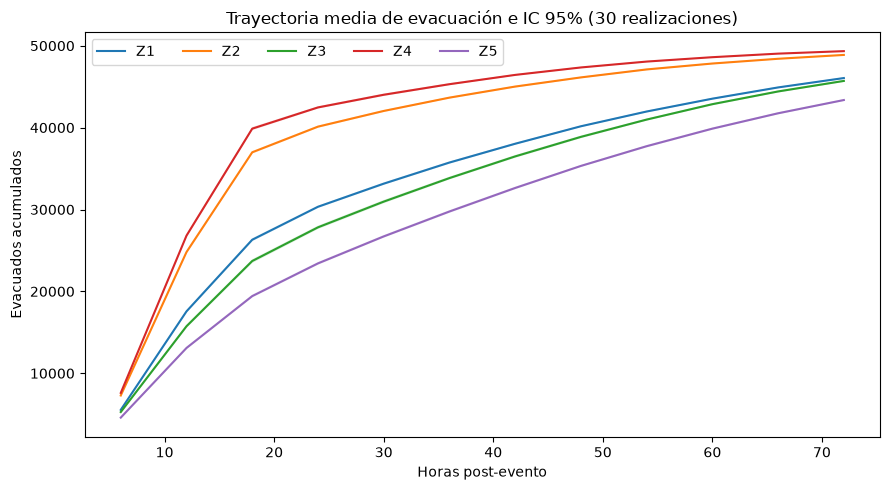

In [5]:
def bootstrap_ic95(muestras, B=2000, seed=0):
    """IC 95% no parametrico sobre el eje de realizaciones."""
    r = np.random.default_rng(seed)
    muestras = np.asarray(muestras)
    n = muestras.shape[0]
    indices = r.integers(0, n, size=(B, n))
    remuestreos = muestras[indices].mean(axis=1)
    media = muestras.mean(axis=0)
    lo = np.percentile(remuestreos, 2.5, axis=0)
    hi = np.percentile(remuestreos, 97.5, axis=0)
    return media, lo, hi


def correr_monte_carlo(
    campana_activa=False,
    efectividad_senalizacion=0.0,
    n_real=m.N_REALIZACIONES,
    semilla_base=1000,
):
    trayectorias = []
    corridas = []
    for i in range(n_real):
        res = m.correr_realizacion(
            A,
            red,
            zona_de_agente,
            semilla=semilla_base + i,
            campana_activa=campana_activa,
            efectividad_senalizacion=efectividad_senalizacion,
        )
        trayectorias.append(res["evacuados_por_zona_paso"])
        corridas.append(res)
    return np.array(trayectorias), corridas


def media_ic95(trayectorias):
    return bootstrap_ic95(trayectorias)


trayectorias_base, corridas_base = correr_monte_carlo(campana_activa=False)
media_base, lo_base, hi_base = media_ic95(trayectorias_base)

horas = np.arange(1, m.N_PASOS + 1) * 6
fig, ax = plt.subplots()
for z, nombre in enumerate(m.ZONAS):
    ax.plot(horas, media_base[:, z], label=nombre)
    ax.fill_between(horas, lo_base[:, z], hi_base[:, z], alpha=0.15)
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Evacuados acumulados")
ax.set_title("Trayectoria media de evacuación e IC 95% (30 realizaciones)")
ax.legend(ncol=5)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "trayectorias_evacuacion_ic95.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Outputs formales para Grupo 1 (Seccion 5 del Excel)

Grupo 6 entrega a Grupo 1: **(a)** flujo nuevo de desplazados por zona de
origen, zona de destino y bloque de seis horas, con media e IC 95%; **(b)**
personas que no pudieron evacuar sin asistencia en Z1 y Z5 por bloque; y
**(c)** matriz acumulada de rutas preferidas entre cada par de zonas. Los
tres resultados se exportan a `data/processed/`.

In [6]:
# (a) Flujo de desplazados por bloque, origen y destino
flujos_por_corrida = np.array([
    resultado["flujo_destino_zona_paso"] for resultado in corridas_base
])
media_flujo, lo_flujo, hi_flujo = bootstrap_ic95(flujos_por_corrida)

filas_a = []
for t in range(m.N_PASOS):
    for origen in range(m.N_ZONAS):
        for destino in range(m.N_ZONAS):
            filas_a.append({
                "bloque_tiempo": t + 1,
                "hora_post_evento": (t + 1) * 6,
                "zona_origen": m.ZONAS[origen],
                "zona_destino": m.ZONAS[destino],
                "tipo_destino": (
                    "refugio_oficial" if origen == destino else "otra_zona"
                ),
                "nuevos_desplazados_media": media_flujo[t, origen, destino],
                "ic95_inferior": lo_flujo[t, origen, destino],
                "ic95_superior": hi_flujo[t, origen, destino],
            })
df_a = pd.DataFrame(filas_a)
df_a.to_csv(OUTPUT_DIR / "output_a_flujo_desplazados.csv", index=False)
df_a.head(10)

,bloque_tiempo,hora_post_evento,zona_origen,zona_destino,tipo_destino,nuevos_desplazados_media,ic95_inferior,ic95_superior
0,1,6,Z1,Z1,refugio_oficial,3250.000000,3172.500000,3329.187500
1,1,6,Z1,Z2,otra_zona,552.500000,516.666667,588.333333
2,1,6,Z1,Z3,otra_zona,580.833333,544.145833,624.166667
3,1,6,Z1,Z4,otra_zona,572.500000,519.979167,630.020833
4,1,6,Z1,Z5,otra_zona,580.000000,540.000000,621.666667
5,1,6,Z2,Z1,otra_zona,1115.833333,1067.500000,1169.166667
6,1,6,Z2,Z2,refugio_oficial,3050.833333,2955.000000,3150.000000
7,1,6,Z2,Z3,otra_zona,1090.833333,1027.500000,1150.000000
8,1,6,Z2,Z4,otra_zona,995.000000,923.312500,1059.208333
9,1,6,Z2,Z5,otra_zona,1036.666667,979.166667,1097.500000


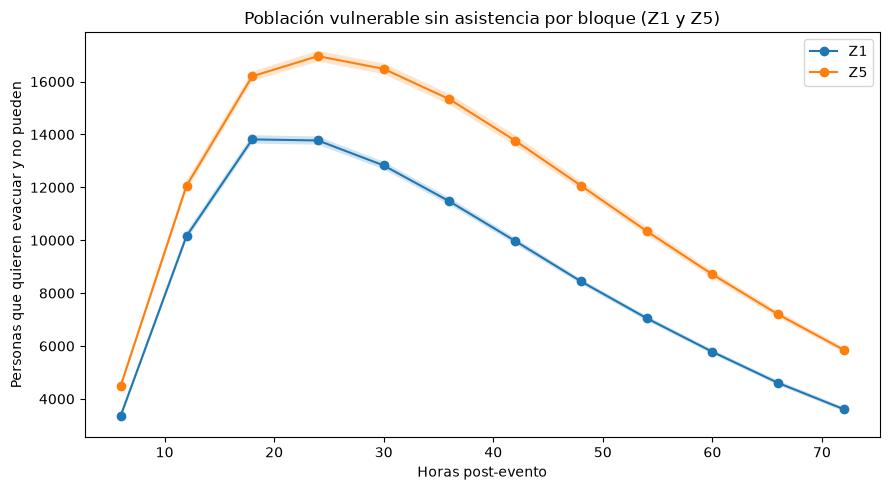

,zona,bloque_tiempo,hora_post_evento,personas_sin_poder_evacuar_media,ic95_inferior,ic95_superior
0,Z1,1,6,3370.833333,3256.645833,3480.854167
1,Z1,2,12,10157.500000,9998.333333,10316.666667
2,Z1,3,18,13815.000000,13654.145833,13973.354167
3,Z1,4,24,13774.166667,13615.812500,13925.833333
4,Z1,5,30,12828.333333,12682.458333,12972.520833
5,Z1,6,36,11470.833333,11335.000000,11606.687500
6,Z1,7,42,9972.500000,9847.479167,10094.166667
7,Z1,8,48,8445.833333,8343.333333,8541.666667
8,Z1,9,54,7052.500000,6955.812500,7145.000000
9,Z1,10,60,5780.833333,5693.312500,5868.354167


In [7]:
# (b) Personas que NO podran evacuar sin asistencia en Z1 y Z5, por bloque
def atrapados_por_bloque(corridas, zona_nombre):
    z = m.ZONAS.index(zona_nombre)
    conteos = []
    for res in corridas:
        mask_zona = res["zona_de_agente"] == z
        atrapado = res["quiere_pero_no_puede"][:, mask_zona].sum(axis=1) * m.FACTOR_ESCALA[z]
        conteos.append(atrapado)
    conteos = np.array(conteos)  # (n_real, n_pasos)
    return bootstrap_ic95(conteos)


filas_b = []
for zona_nombre in ("Z1", "Z5"):
    media_b, lo_b, hi_b = atrapados_por_bloque(corridas_base, zona_nombre)
    for t in range(m.N_PASOS):
        filas_b.append({
            "zona": zona_nombre, "bloque_tiempo": t + 1, "hora_post_evento": (t + 1) * 6,
            "personas_sin_poder_evacuar_media": media_b[t],
            "ic95_inferior": lo_b[t], "ic95_superior": hi_b[t],
        })
df_b = pd.DataFrame(filas_b)
df_b.to_csv(OUTPUT_DIR / "output_b_atrapados_sin_asistencia.csv", index=False)

fig, ax = plt.subplots()
for zona_nombre in ("Z1", "Z5"):
    sub = df_b[df_b["zona"] == zona_nombre]
    ax.plot(sub["hora_post_evento"], sub["personas_sin_poder_evacuar_media"], marker="o", label=zona_nombre)
    ax.fill_between(sub["hora_post_evento"], sub["ic95_inferior"], sub["ic95_superior"], alpha=0.2)
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Personas que quieren evacuar y no pueden")
ax.set_title("Población vulnerable sin asistencia por bloque (Z1 y Z5)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "asistencia_pendiente_z1_z5_ic95.png", dpi=180, bbox_inches="tight")
plt.show()
df_b.head(10)


In [8]:
# (c) Matriz acumulada de rutas preferidas por origen y destino
flujos_acumulados_corrida = flujos_por_corrida.sum(axis=1)
media_c, lo_c, hi_c = bootstrap_ic95(flujos_acumulados_corrida)

filas_c = []
for origen in range(m.N_ZONAS):
    total_origen = media_c[origen].sum()
    for destino in range(m.N_ZONAS):
        filas_c.append({
            "zona_origen": m.ZONAS[origen],
            "zona_destino": m.ZONAS[destino],
            "tipo_destino": (
                "refugio_oficial" if origen == destino else "otra_zona"
            ),
            "evacuados_media": media_c[origen, destino],
            "ic95_inferior": lo_c[origen, destino],
            "ic95_superior": hi_c[origen, destino],
            "porcentaje_del_flujo_origen": (
                media_c[origen, destino] / total_origen if total_origen else 0.0
            ),
        })
df_c = pd.DataFrame(filas_c)
df_c.to_csv(OUTPUT_DIR / "output_c_rutas_preferidas.csv", index=False)

resumen_rutas = []
for origen in range(m.N_ZONAS):
    total = media_c[origen].sum()
    oficial = media_c[origen, origen]
    otra = total - oficial
    resumen_rutas.append({
        "zona": m.ZONAS[origen],
        "evacuados_hacia_refugio_oficial": oficial,
        "evacuados_hacia_otra_zona": otra,
        "pct_que_se_desvia_del_refugio_oficial": otra / total if total else 0.0,
    })
resumen_rutas = pd.DataFrame(resumen_rutas).sort_values(
    "pct_que_se_desvia_del_refugio_oficial", ascending=False
)
display(resumen_rutas)
display(df_c.head(10))

,zona,evacuados_hacia_refugio_oficial,evacuados_hacia_otra_zona,pct_que_se_desvia_del_refugio_oficial
3,Z4,17148.333333,32190.000000,0.652434
1,Z2,20405.833333,28470.000000,0.582496
0,Z1,26806.666667,19245.833333,0.417911
2,Z3,31535.000000,14165.833333,0.309969
4,Z5,33871.666667,9495.833333,0.218962


,zona_origen,zona_destino,tipo_destino,evacuados_media,ic95_inferior,ic95_superior,porcentaje_del_flujo_origen
0,Z1,Z1,refugio_oficial,26806.666667,26635.000000,26977.541667,0.582089
1,Z1,Z2,otra_zona,4853.333333,4730.000000,4976.666667,0.105387
2,Z1,Z3,otra_zona,4812.500000,4683.312500,4945.020833,0.104500
3,Z1,Z4,otra_zona,4741.666667,4641.666667,4841.687500,0.102962
4,Z1,Z5,otra_zona,4838.333333,4726.666667,4946.666667,0.105061
5,Z2,Z1,otra_zona,7227.500000,7094.958333,7361.687500,0.147875
6,Z2,Z2,refugio_oficial,20405.833333,20227.500000,20585.854167,0.417504
7,Z2,Z3,otra_zona,7072.500000,6943.312500,7198.333333,0.144703
8,Z2,Z4,otra_zona,7055.000000,6852.458333,7245.041667,0.144345
9,Z2,Z5,otra_zona,7115.000000,6959.166667,7286.687500,0.145573


## 6. Pregunta 1 (Análisis propio): autoevacuación en Z1 y Z5, primeras 12 h

La consigna se responde usando como denominador la **población total de cada
zona**. También se reporta, como dato complementario, la fracción condicional
de la población no autónoma (necesita asistencia y dependiente) que quiso
evacuar durante las primeras 12 horas y no pudo por falta de asistencia. La
ventana crítica se identifica con el bloque de mayor flujo de nuevas
evacuaciones y se contrasta con la trayectoria del backlog.

In [9]:
def fraccion_atrapados_primeras_12h(corridas, zona_nombre):
    z = m.ZONAS.index(zona_nombre)
    fracciones_totales = []
    fracciones_no_autonomas = []
    for res in corridas:
        mask_zona = res["zona_de_agente"] == z
        atrapado_12h = res["quiere_pero_no_puede"][0:2, mask_zona].any(axis=0)
        no_autonomo = res["tier"][mask_zona] != "autonomo"
        fracciones_totales.append(atrapado_12h.mean())
        fracciones_no_autonomas.append(atrapado_12h[no_autonomo].mean())

    return (
        bootstrap_ic95(np.asarray(fracciones_totales)),
        bootstrap_ic95(np.asarray(fracciones_no_autonomas)),
    )


for zona_nombre in ("Z1", "Z5"):
    total, condicional = fraccion_atrapados_primeras_12h(corridas_base, zona_nombre)
    media_total, lo_total, hi_total = total
    media_cond, lo_cond, hi_cond = condicional
    print(
        f"{zona_nombre}: {100 * media_total:.1f}% de la población total no pudo "
        f"autoevacuar en las primeras 12 h "
        f"(IC95%: [{100 * lo_total:.1f}%, {100 * hi_total:.1f}%]); "
        f"equivale a {100 * media_cond:.1f}% de la población no autónoma "
        f"(IC95%: [{100 * lo_cond:.1f}%, {100 * hi_cond:.1f}%])."
    )

Z1: 20.7% de la población total no pudo autoevacuar en las primeras 12 h (IC95%: [20.4%, 21.1%]); equivale a 52.5% de la población no autónoma (IC95%: [51.8%, 53.2%]).
Z5: 24.6% de la población total no pudo autoevacuar en las primeras 12 h (IC95%: [24.3%, 25.0%]); equivale a 47.5% de la población no autónoma (IC95%: [47.0%, 48.1%]).


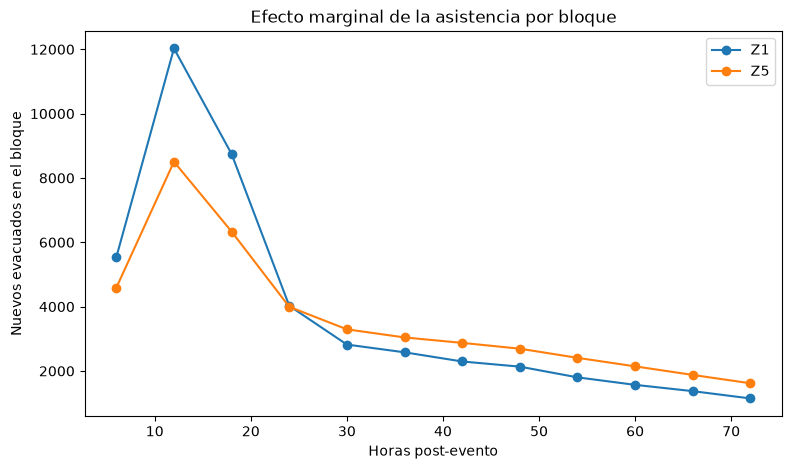

Z1: ventana critica bloque 2 (horas 6-12); backlog maximo 13,815 personas a las 18 h; baja a la mitad a las 60 h.
Z5: ventana critica bloque 2 (horas 6-12); backlog maximo 16,963 personas a las 24 h; baja a la mitad a las 66 h.
Despues de las primeras 12 horas disminuye el beneficio marginal: la mayor cohorte que decidio evacuar ya recibio ayuda o quedo en espera, y en los bloques siguientes el backlog se reduce, por lo que cada refuerzo adicional encuentra menos personas pendientes.


In [10]:
nuevos_medio_z1_z5 = np.array([
    resultado["nuevos_por_zona_paso"] for resultado in corridas_base
]).mean(axis=0)

fig, ax = plt.subplots()
for zona_nombre in ("Z1", "Z5"):
    z = m.ZONAS.index(zona_nombre)
    ax.plot(horas, nuevos_medio_z1_z5[:, z], marker="o", label=zona_nombre)
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Nuevos evacuados en el bloque")
ax.set_title("Efecto marginal de la asistencia por bloque")
ax.legend()
plt.show()

for zona_nombre in ("Z1", "Z5"):
    z = m.ZONAS.index(zona_nombre)
    bloque_critico = int(np.argmax(nuevos_medio_z1_z5[:, z])) + 1
    sub = df_b[df_b["zona"] == zona_nombre].reset_index(drop=True)
    pico_indice = int(sub["personas_sin_poder_evacuar_media"].idxmax() - sub.index.min())
    pico = float(sub.loc[pico_indice, "personas_sin_poder_evacuar_media"])
    posteriores = sub.loc[pico_indice + 1:]
    mitad = posteriores[posteriores["personas_sin_poder_evacuar_media"] <= pico / 2]
    hora_mitad = int(mitad.iloc[0]["hora_post_evento"]) if not mitad.empty else None
    print(
        f"{zona_nombre}: ventana critica bloque {bloque_critico} "
        f"(horas {(bloque_critico - 1) * 6}-{bloque_critico * 6}); "
        f"backlog maximo {pico:,.0f} personas a las "
        f"{int(sub.loc[pico_indice, 'hora_post_evento'])} h; "
        + (
            f"baja a la mitad a las {hora_mitad} h."
            if hora_mitad is not None
            else "no baja a la mitad dentro de las 72 h."
        )
    )

print(
    "Despues de las primeras 12 horas disminuye el beneficio marginal: "
    "la mayor cohorte que decidio evacuar ya recibio ayuda o quedo en espera, "
    "y en los bloques siguientes el backlog se reduce, por lo que cada refuerzo "
    "adicional encuentra menos personas pendientes."
)

## 7. Pregunta 2 (Analisis propio): rutas modeladas y escenario de senalizacion

Con los datos disponibles, la **ruta operativamente planificada** se aproxima
como el traslado al refugio oficial de la zona de origen. El Excel no contiene
capacidad vial ni una matriz de rutas optimas; por eso no se atribuye al modelo
un cuello de botella fisico que no puede observar. La ruta modelada conserva la
zona de destino concreta. Cuando una persona se desvia, el destino social se
asigna uniformemente entre las otras cuatro zonas porque el archivo solo
informa el porcentaje de contactos externos, no los pares de zonas.

La intervencion evaluada combina senales direccionales en puntos de salida y
mensajes oficiales geolocalizados que nombran el refugio asignado. Como no hay
una efectividad empirica en el Excel, se declara un escenario de **50% de
efectividad**: la mitad de quienes se desviarian permanece en la ruta oficial.
Se usan las mismas 30 semillas para medir cuantas personas cambia de ruta sin
confundir el efecto con variacion aleatoria entre corridas.

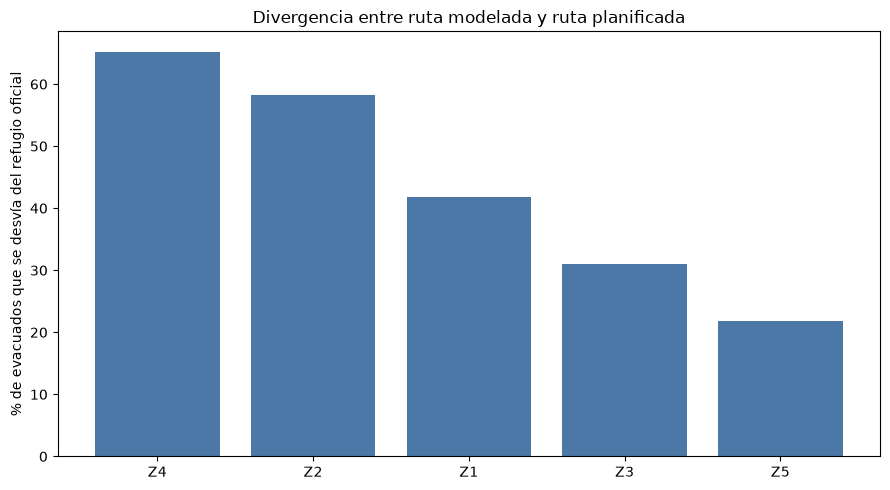

Mayor cuello de botella de planificacion: Z4 (65.2% se dirige a otra zona).


,zona,desvios_base_media,desvios_con_senalizacion_media,personas_redirigidas_media,ic95_inferior,ic95_superior,reduccion_porcentual
3,Z4,32190.000000,16036.666667,16153.333333,15948.333333,16365.833333,0.501812
1,Z2,28470.000000,14181.666667,14288.333333,14107.458333,14478.375000,0.501873
0,Z1,19245.833333,9640.000000,9605.833333,9485.833333,9730.833333,0.499112
2,Z3,14165.833333,7086.666667,7079.166667,6970.833333,7191.687500,0.499735
4,Z5,9495.833333,4818.333333,4677.500000,4559.166667,4790.854167,0.492584


La senalizacion del 50% redirige en promedio 51,804 personas a su refugio oficial (IC95%: 51,562 a 52,046).


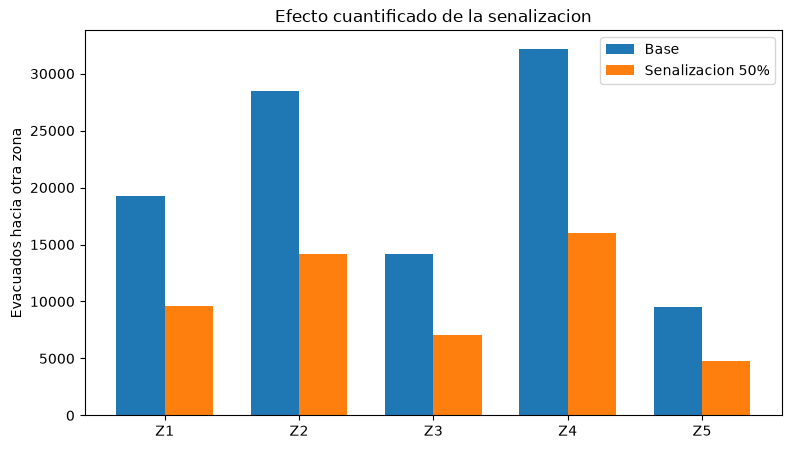

In [11]:
fig, ax = plt.subplots()
ax.bar(
    resumen_rutas["zona"],
    100 * resumen_rutas["pct_que_se_desvia_del_refugio_oficial"],
    color="#4c78a8",
)
ax.set_ylabel("% de evacuados que se desvía del refugio oficial")
ax.set_title("Divergencia entre ruta modelada y ruta planificada")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "divergencia_rutas.png", dpi=180, bbox_inches="tight")
plt.show()

zona_cuello = resumen_rutas.iloc[0]
print(
    f"Mayor cuello de botella de planificacion: {zona_cuello['zona']} "
    f"({100 * zona_cuello['pct_que_se_desvia_del_refugio_oficial']:.1f}% "
    "se dirige a otra zona)."
)

_, corridas_senalizacion = correr_monte_carlo(
    efectividad_senalizacion=0.50,
    semilla_base=1000,
)
flujos_senalizacion = np.array([
    resultado["flujo_destino_zona_paso"]
    for resultado in corridas_senalizacion
]).sum(axis=1)
flujos_base_acumulados = flujos_por_corrida.sum(axis=1)

desvios_base = (
    flujos_base_acumulados.sum(axis=2)
    - np.diagonal(flujos_base_acumulados, axis1=1, axis2=2)
)
desvios_senalizacion = (
    flujos_senalizacion.sum(axis=2)
    - np.diagonal(flujos_senalizacion, axis1=1, axis2=2)
)
redirigidos = desvios_base - desvios_senalizacion
media_redir, lo_redir, hi_redir = bootstrap_ic95(redirigidos)

df_intervencion = pd.DataFrame({
    "zona": m.ZONAS,
    "desvios_base_media": desvios_base.mean(axis=0),
    "desvios_con_senalizacion_media": desvios_senalizacion.mean(axis=0),
    "personas_redirigidas_media": media_redir,
    "ic95_inferior": lo_redir,
    "ic95_superior": hi_redir,
    "reduccion_porcentual": np.divide(
        media_redir,
        desvios_base.mean(axis=0),
        out=np.zeros_like(media_redir),
        where=desvios_base.mean(axis=0) > 0,
    ),
}).sort_values("personas_redirigidas_media", ascending=False)
display(df_intervencion)

total_redirigidos = redirigidos.sum(axis=1)
media_total, lo_total, hi_total = bootstrap_ic95(total_redirigidos)
print(
    f"La senalizacion del 50% redirige en promedio {media_total:,.0f} personas "
    f"a su refugio oficial (IC95%: {lo_total:,.0f} a {hi_total:,.0f})."
)

fig, ax = plt.subplots()
orden = np.arange(m.N_ZONAS)
ax.bar(orden - 0.18, desvios_base.mean(axis=0), width=0.36, label="Base")
ax.bar(
    orden + 0.18,
    desvios_senalizacion.mean(axis=0),
    width=0.36,
    label="Senalizacion 50%",
)
ax.set_xticks(orden, m.ZONAS)
ax.set_ylabel("Evacuados hacia otra zona")
ax.set_title("Efecto cuantificado de la senalizacion")
ax.legend()
plt.show()

El cuello de botella observable con los datos de Grupo 6 es de
**planificacion de refugios**: los desvios hacen que la demanda real por zona
no coincida con la asignacion oficial. La tabla anterior cuantifica el cambio
que produciria la senalizacion en cada zona y el total con IC 95%. La magnitud
es un resultado de escenario, no una estimacion causal observada, porque el
Excel no entrega una tasa empirica de respuesta a senales. Una matriz vial de
Grupo 4 permitiria reemplazar la ruta planificada simplificada y evaluar
cuellos de botella fisicos.

## 8. Pregunta 3 (Analisis propio): efecto de la desinformacion

Se comparan dos escenarios de 30 realizaciones cada uno, usando la
probabilidad real de informacion correcta por zona (Seccion 3 del Excel):
- **Base:** `prob_info_correcta` tal como esta en el Excel (p.ej. Z5: 0.48).
- **Campana oficial activa:** se reduce a la mitad la probabilidad de que
  circule un rumor, es decir `p_correcta_nueva = 1 - (1-p_correcta)/2`.

Ambos escenarios usan las mismas 30 semillas. La diferencia se calcula
por pares para reducir la variacion ajena a la campana.

In [12]:
trayectorias_campana, corridas_campana = correr_monte_carlo(campana_activa=True, semilla_base=1000)
media_campana, lo_campana, hi_campana = media_ic95(trayectorias_campana)

print("Probabilidad de info correcta por zona, base vs. campana:")
comparacion_p = pd.DataFrame({
    "base": m.REDES["prob_info_correcta"].to_numpy(),
    "con_campana": m.prob_info_correcta_campana(True),
}, index=m.ZONAS)
display(comparacion_p)

bloque_48h = 7  # indice 0-based del paso 8 (48h)
diferencia = trayectorias_campana[:, bloque_48h, :] - trayectorias_base[:, bloque_48h, :]
media_dif, lo_dif, hi_dif = bootstrap_ic95(diferencia)

df_dif = pd.DataFrame({
    "zona": m.ZONAS,
    "personas_adicionales_evacuadas_48h": media_dif,
    "ic95_inferior": lo_dif,
    "ic95_superior": hi_dif,
}).sort_values("personas_adicionales_evacuadas_48h", ascending=False)
df_dif


Probabilidad de info correcta por zona, base vs. campana:


,base,con_campana
Z1,0.61,0.805
Z2,0.74,0.870
Z3,0.55,0.775
Z4,0.81,0.905
Z5,0.48,0.740


,zona,personas_adicionales_evacuadas_48h,ic95_inferior,ic95_superior
4,Z5,593.333333,437.479167,740.000000
2,Z3,509.166667,358.312500,645.833333
0,Z1,306.666667,138.291667,476.666667
1,Z2,155.000000,46.666667,265.854167
3,Z4,84.166667,-19.187500,190.000000


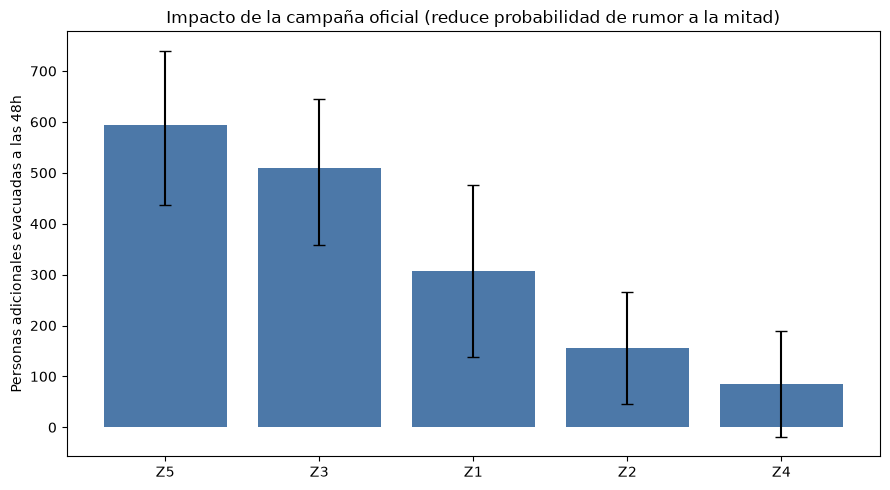

La zona donde la diferencia es mas significativa es Z5.


In [13]:
fig, ax = plt.subplots()
ax.bar(df_dif["zona"], df_dif["personas_adicionales_evacuadas_48h"],
       yerr=[df_dif["personas_adicionales_evacuadas_48h"] - df_dif["ic95_inferior"],
             df_dif["ic95_superior"] - df_dif["personas_adicionales_evacuadas_48h"]],
       capsize=4, color="#4c78a8")
ax.set_ylabel("Personas adicionales evacuadas a las 48h")
ax.set_title("Impacto de la campaña oficial (reduce probabilidad de rumor a la mitad)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "impacto_campana_desinformacion_ic95.png", dpi=180, bbox_inches="tight")
plt.show()

zona_mas_impacto = df_dif.iloc[0]["zona"]
print(f"La zona donde la diferencia es mas significativa es {zona_mas_impacto}.")


## 8.1 Analisis de sensibilidad: incertidumbre de medicion en el Excel

La conclusion de la Pregunta 3 depende de `P_SIGUE_OFICIAL` (probabilidad
de seguir instrucciones oficiales en vez de un rumor): el Excel lo reporta
como un punto fijo, 0.54, pero es una estimacion de encuesta de
comportamiento y toda encuesta tiene margen de error de muestreo, no es un
valor exacto de la realidad, aunque el archivo lo entregue con un solo
decimal fijo. En vez de repetir la comparacion entre campana y base solo
con distinta semilla aleatoria del modelo (que ya se hizo en la seccion
anterior), aqui se repite variando el valor mismo de `P_SIGUE_OFICIAL`
entre 0.39 y 0.69 (un margen de error de muestreo plausible alrededor de
0.54), para ver si el patron de que zonas se benefician mas de la campana
se mantiene o depende criticamente del decimal exacto que dio el Excel.

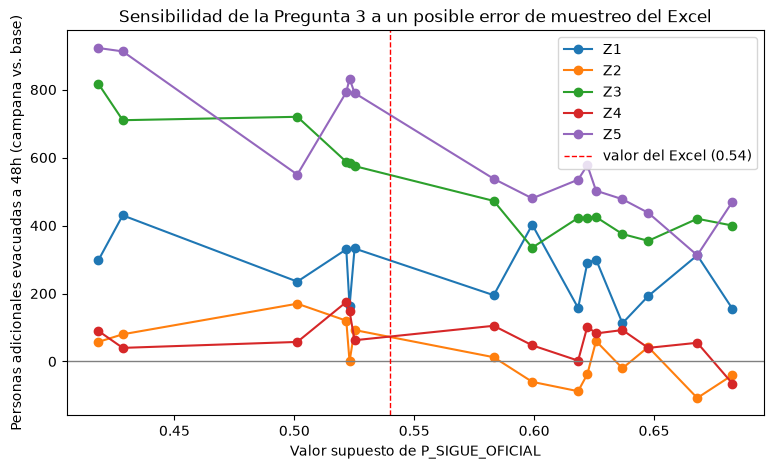

Zona mas beneficiada por la campana, segun cada valor muestreado de P_SIGUE_OFICIAL:
Z5    13
Z3     2
Name: count, dtype: int64


In [14]:
def diferencia_por_zona_bajo_confianza_oficial(valor_p_sigue_oficial, n_real=10, semilla_base=9000):
    original = m.P_SIGUE_OFICIAL
    m.P_SIGUE_OFICIAL = valor_p_sigue_oficial
    try:
        tb, _ = correr_monte_carlo(campana_activa=False, n_real=n_real, semilla_base=semilla_base)
        tc, _ = correr_monte_carlo(campana_activa=True, n_real=n_real, semilla_base=semilla_base)
    finally:
        m.P_SIGUE_OFICIAL = original  # se restaura sin importar el resultado
    dif = tc[:, bloque_48h, :] - tb[:, bloque_48h, :]
    return dif.mean(axis=0)


rng_param = np.random.default_rng(42)
valores_confianza = np.sort(rng_param.uniform(0.39, 0.69, size=15))
resultados_sensibilidad = np.array([diferencia_por_zona_bajo_confianza_oficial(v) for v in valores_confianza])

df_sens = pd.DataFrame(resultados_sensibilidad, columns=m.ZONAS)
df_sens.insert(0, "p_sigue_oficial", valores_confianza)

fig, ax = plt.subplots()
for z_nombre in m.ZONAS:
    ax.plot(df_sens["p_sigue_oficial"], df_sens[z_nombre], "o-", label=z_nombre)
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0.54, color="red", linestyle="--", linewidth=1, label="valor del Excel (0.54)")
ax.set_xlabel("Valor supuesto de P_SIGUE_OFICIAL")
ax.set_ylabel("Personas adicionales evacuadas a 48h (campana vs. base)")
ax.set_title("Sensibilidad de la Pregunta 3 a un posible error de muestreo del Excel")
ax.legend()
plt.show()

zona_mas_beneficiada_por_muestra = df_sens[list(m.ZONAS)].idxmax(axis=1)
print("Zona mas beneficiada por la campana, segun cada valor muestreado de P_SIGUE_OFICIAL:")
print(zona_mas_beneficiada_por_muestra.value_counts())


## 9. Incorporacion del intercambio presencial

Segun la tabla de dependencias del examen, nuestro grupo unicamente
entrega la proyeccion de flujo de desplazados a Grupo 1 (outputs a, b, c de
la seccion 5), pero no figura como receptor formal de ningun otro grupo.

## 10. Limitaciones y propuestas de mejora

1. **Poblacion por zona asumida igualitaria (50,000 c/u):** el Excel de
   Grupo 6 no incluye este dato; con mas tiempo se solicitaria explicitamente
   al catedratico o se validaria contra el dato que sí maneja Grupo 1.
2. **Escala de agentes:** se simulan 2,000 agentes representativos por zona
   (10,000 en total) en vez de 250,000 habitantes reales, mediante un factor
   de escala. Se valido que el grado promedio de la red simulada coincide
   con el del Excel (seccion 3), pero no se valido que el factor de escala
   no distorsione la velocidad de propagacion a nivel poblacional completo.
3. **Capacidad de asistencia/rescate sin dato propio:** Grupo 6 no recibe el
   plan de despliegue de Grupo 5, asi que `prob_asistencia()` es una funcion
   generica calibrada solo con el `indice_riesgo_rezago` propio de cada
   zona. Si se recibiera el dato real de Grupo 5, se reemplazaria esa
   funcion directamente.
4. **Ruta planificada y destinos sociales simplificados:** se compara contra
   ir al refugio oficial de la zona y, ante la ausencia de una matriz
   origen-destino, los viajes sociales se distribuyen uniformemente entre
   las otras cuatro zonas. Los datos de capacidad vial permitirian sustituir
   ambos supuestos y localizar cuellos de botella fisicos.
5. **Actualizacion sincrona por bloque:** dentro de cada bloque de 6h todas
   las decisiones se calculan a partir del mismo estado inicial del bloque,
   sin orden de activacion entre agentes. Esto es razonable a la escala de
   6h que impone el Excel, pero si se quisiera capturar el orden exacto en
   que las decisiones se propagan dentro de una misma ventana de horas
   (p. ej. quien se entera primero dentro del mismo bloque), haria falta
   una resolucion temporal mas fina con activacion secuencial, lo cual
   multiplicaria el costo computacional.